## 1. Configuración y descarga

In [1]:
IMAGENES_URL = 'https://drive.google.com/file/d/1n4gSJTpws7AnECs0x2f7X_tiSNy_Dr5G/view?usp=sharing'
K_GRUPOS = 8

!pip install -q ultralytics gdown
import cv2, numpy as np, math, random, shutil, zipfile, gdown
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans

shutil.rmtree('imagenes', ignore_errors=True)          # evita mezclar con descargas anteriores
gdown.download(IMAGENES_URL, 'imagenes.zip', fuzzy=True, quiet=True)
zipfile.ZipFile('imagenes.zip').extractall('imagenes')
IMAGENES = sorted(p for p in Path('imagenes').rglob('*')
                  if p.suffix.lower() in ('.jpg', '.jpeg', '.png') and '__MACOSX' not in p.parts)
print(len(IMAGENES), 'imagenes, por ejemplo:', [p.name for p in IMAGENES[:3]])

def ver(imgs, titulos, ancho=5):
    fig, ejes = plt.subplots(1, len(imgs), figsize=(ancho * len(imgs), ancho))
    for ax, im, t in zip(np.atleast_1d(ejes), imgs, titulos):
        ax.imshow(im if im.ndim == 2 else im[..., ::-1], cmap='gray'); ax.set_title(t); ax.axis('off')
    plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 10.6 MB/s eta 0:00:00
68 imagenes, por ejemplo: ['10_4x4.jpeg', '10_5x5.jpeg', '10_6x6.jpeg']


## 2. Preprocesamiento y segmentación
Escala de grises → binarización adaptativa → celdas → corrección de perspectiva → grilla N×N → recortes de cada celda y de cada hueco entre celdas.

In [2]:
S, M = 800, 30   # tamaño del tablero rectificado y margen

def preprocesar(img, C=10):
    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    bloque = max(15, (min(gris.shape) // 40) | 1)
    binaria = cv2.adaptiveThreshold(cv2.GaussianBlur(gris, (5, 5), 0), 255,
                                    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, bloque, C)
    k = max(3, min(gris.shape) // 300)        # cierra cortes pequeños en los bordes de las celdas
    return gris, cv2.morphologyEx(binaria, cv2.MORPH_CLOSE, np.ones((k, k), np.uint8))

def detectar_celdas(binaria):
    """Contornos cuadrados y solidos; se queda con los de tamaño mas repetido."""
    t, cand = min(binaria.shape), []
    for c in cv2.findContours(binaria, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)[0]:
        area = cv2.contourArea(c)
        (cx, cy), (w, h), _ = cv2.minAreaRect(c)
        if (t * .03) ** 2 < area < (t * .5) ** 2 and 0.75 < w / h < 1.33 \
                and area / cv2.contourArea(cv2.convexHull(c)) > 0.85 and area / (w * h) > 0.75:
            cand.append((math.sqrt(area), cx, cy, c))
    celdas = []
    for d in sorted(cand, key=lambda d: -d[0]):          # cada celda da 2 contornos: se queda el mayor
        if all(math.hypot(d[1] - e[1], d[2] - e[2]) > .35 * e[0] for e in celdas):
            celdas.append(d)
    if not celdas:
        return []
    lados = np.array([d[0] for d in celdas])
    s = lados[np.argmax([np.sum(abs(lados - l) < .25 * l) for l in lados])]
    return [d for d in celdas if abs(d[0] - s) < .3 * s]

def rectificar(img, celdas):
    """Homografia usando la esquina exterior de las 4 celdas extremas."""
    c = np.array([[d[1], d[2]] for d in celdas])
    esquina = lambda i, sx, sy: max(celdas[i][3].reshape(-1, 2), key=lambda p: sx * p[0] + sy * p[1])
    src = np.float32([esquina(np.argmin(c.sum(1)), -1, -1), esquina(np.argmax(c[:, 0] - c[:, 1]), 1, -1),
                      esquina(np.argmax(c.sum(1)), 1, 1), esquina(np.argmin(c[:, 0] - c[:, 1]), -1, 1)])
    H = cv2.getPerspectiveTransform(src, np.float32([[M, M], [S - M, M], [S - M, S - M], [M, S - M]]))
    return cv2.warpPerspective(img, H, (S, S), borderValue=(255, 255, 255)), src

def analizar(img):
    """Preprocesa, corrige la perspectiva y segmenta la grilla."""
    cuadrado = lambda n: n >= 9 and round(math.sqrt(n)) ** 2 == n
    for C in (10, 5, 2):                      # si la foto esta borrosa, se binariza de forma mas tolerante
        gris, binaria = preprocesar(img, C)
        celdas = detectar_celdas(binaria)
        if cuadrado(len(celdas)):
            break
    if len(celdas) < 9:
        raise ValueError(f'solo {len(celdas)} celdas')
    rect, esquinas = rectificar(img, celdas)
    bin_rect = preprocesar(rect, C)[1]
    celdas_r = detectar_celdas(bin_rect)
    if cuadrado(len(celdas_r)) and len(celdas_r) > len(celdas):   # ya enderezado se ven celdas que faltaban
        celdas = celdas_r
        rect = rectificar(rect, celdas_r)[0]
        bin_rect = preprocesar(rect, C)[1]
        celdas_r = detectar_celdas(bin_rect)
    N = round(math.sqrt(len(celdas)))
    lado = float(np.median([d[0] for d in celdas_r])) if celdas_r else (S - 2 * M) / (1.4 * N)
    paso = (S - 2 * M - lado) / (N - 1)
    centro = lambda r, c: (M + lado / 2 + c * paso, M + lado / 2 + r * paso)
    return dict(gris=gris, binaria=binaria, celdas=celdas, esquinas=esquinas, rect=rect, bin_rect=bin_rect,
                N=N, lado=lado, hueco=paso - lado, centro=centro)

def recortar(a, tam=96):
    """Un recorte por celda y por hueco, con su 'tinta' (fraccion de pixeles oscuros)."""
    N, lado, hueco, centro = a['N'], a['lado'], a['hueco'], a['centro']
    pos = [('celda', r, c, *centro(r, c)) for r in range(N) for c in range(N)]
    pos += [('h', r, c, (centro(r, c)[0] + centro(r, c + 1)[0]) / 2, centro(r, c)[1]) for r in range(N) for c in range(N - 1)]
    pos += [('v', r, c, centro(r, c)[0], (centro(r, c)[1] + centro(r + 1, c)[1]) / 2) for r in range(N - 1) for c in range(N)]
    out = []
    for tipo, r, c, x, y in pos:
        s = lado * .8 if tipo == 'celda' else hueco * .95
        caja = lambda k: (slice(int(y - k * s / 2), int(y + k * s / 2)), slice(int(x - k * s / 2), int(x + k * s / 2)))
        img = cv2.resize(a['rect'][caja(1)], (tam, tam), interpolation=cv2.INTER_AREA)
        out.append(dict(tipo=tipo, pos=(r, c), img=img, tinta=float(np.mean(a['bin_rect'][caja(.75)] > 0))))
    return out

Ejemplo: 10_4x4.jpeg


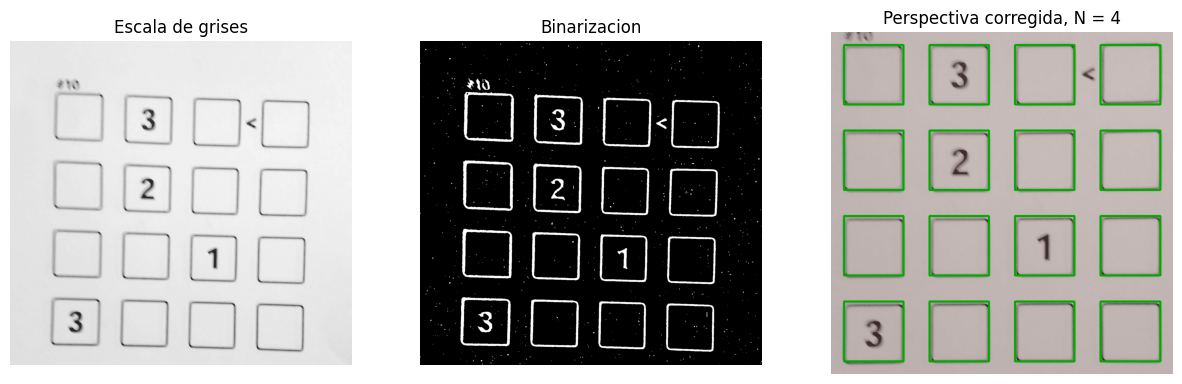

In [3]:
for ruta in IMAGENES:
    img = cv2.imread(str(ruta))
    try:
        a = analizar(img); break
    except ValueError as e:
        print('sin grilla:', ruta.name, e)
        ver([img, preprocesar(img)[1]], [ruta.name, 'Binarizacion'])
print('Ejemplo:', ruta.name)
grilla = a['rect'].copy()
for r in range(a['N']):
    for c in range(a['N']):
        x, y = a['centro'](r, c); l = a['lado'] / 2
        cv2.rectangle(grilla, (int(x - l), int(y - l)), (int(x + l), int(y + l)), (0, 170, 0), 3)
ver([a['gris'], a['binaria'], grilla], ['Escala de grises', 'Binarizacion', f"Perspectiva corregida, N = {a['N']}"])

## 3. Lectura de signos con OpenCV
Los recortes vacíos se separan por la cantidad de tinta. En cada hueco con tinta, el signo se lee por geometría: el trazo es angosto en el vértice y ancho en el lado abierto, y el vértice apunta a la celda menor.

vacios: 3265 | digitos: 792 | signos: {'<': 165, '>': 221, '^': 203, 'v': 193}


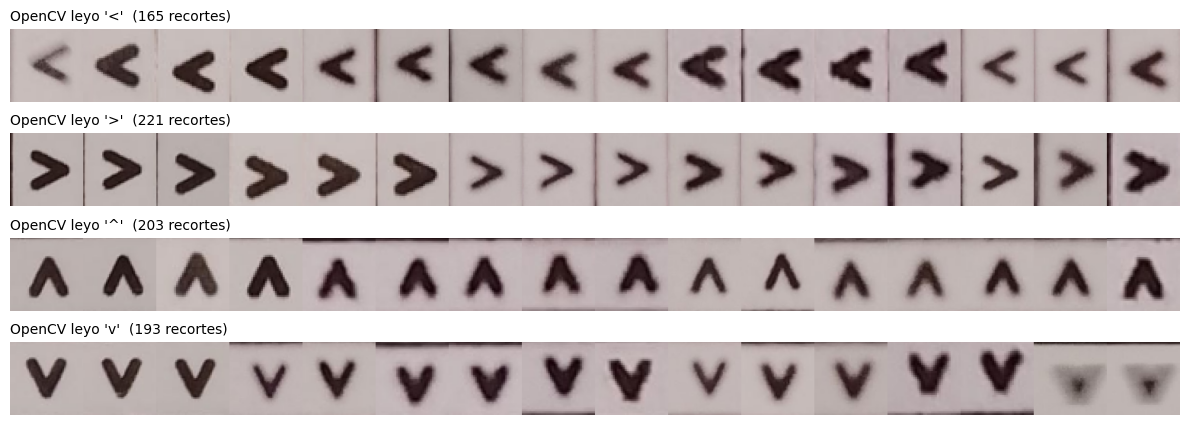

In [4]:
def leer_signo(img, tipo):
    """Regla geometrica: el signo es angosto en su vertice y ancho en su lado abierto.
    La punta siempre apunta a la celda menor."""
    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)[10:-10, 10:-10]
    b = cv2.threshold(gris, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
    n, comp, stats, _ = cv2.connectedComponentsWithStats(b)
    ys, xs = np.nonzero(comp == 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA]))   # trazo principal
    a, c = (xs, ys) if tipo == 'h' else (ys, xs)          # a: eje a lo largo del hueco, c: eje transversal
    t = (a.max() - a.min()) * .3
    punta_al_inicio = np.ptp(c[a <= a.min() + t]) < np.ptp(c[a >= a.max() - t])
    if tipo == 'h':
        return 'less_than' if punta_al_inicio else 'greater_than'     # punta a la izquierda: <
    return 'up_than' if punta_al_inicio else 'down_than'              # punta arriba: ^

SIMBOLO = {'less_than': '<', 'greater_than': '>', 'up_than': '^', 'down_than': 'v'}
DIGITOS, VACIOS, SIGNOS = [], [], {s: [] for s in SIMBOLO}
for ruta in IMAGENES:
    try:
        for rc in recortar(analizar(cv2.imread(str(ruta)))):
            if rc['tinta'] < 0.025:
                VACIOS.append(rc['img'])
            elif rc['tipo'] == 'celda':
                DIGITOS.append(rc['img'])
            else:
                SIGNOS[leer_signo(rc['img'], rc['tipo'])].append(rc['img'])
    except Exception as e:
        print('sin grilla:', ruta.name, e)
print(f'vacios: {len(VACIOS)} | digitos: {len(DIGITOS)} | signos:', {SIMBOLO[k]: len(v) for k, v in SIGNOS.items()})

# Revision visual: cada fila deberia tener un solo tipo de signo
fig, ejes = plt.subplots(4, 1, figsize=(12, 4.4))
for ax, (s, imgs) in zip(ejes, SIGNOS.items()):
    ax.imshow(np.hstack(imgs[:16] or [np.full((96, 96, 3), 255, np.uint8)])[..., ::-1]); ax.axis('off')
    ax.set_title(f"OpenCV leyo '{SIMBOLO[s]}'  ({len(imgs)} recortes)", loc='left', fontsize=10)
plt.tight_layout(); plt.show()

## 4. Dígitos agrupados automáticamente
Los recortes de celdas con contenido se agrupan por parecido (K-means), así solo hay que nombrar cada grupo una vez.

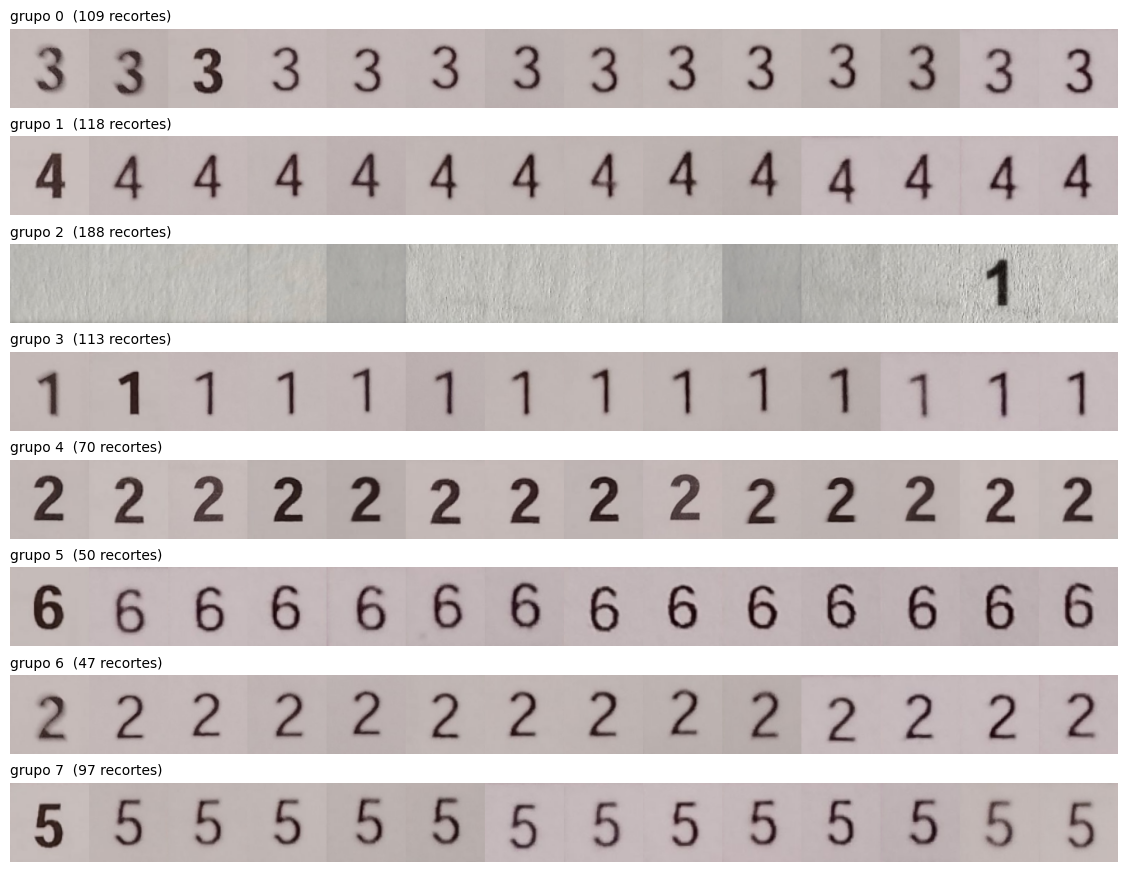

In [5]:
def rasgos(img):
    """Recorte -> vector: binariza, encuadra el trazo y lo reduce a 24x24."""
    g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)[10:-10, 10:-10]
    b = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
    ys, xs = np.nonzero(b)
    if len(ys) == 0:
        return np.zeros(24 * 24)
    b = b[ys.min():ys.max() + 1, xs.min():xs.max() + 1]
    t = max(b.shape)
    b = cv2.copyMakeBorder(b, (t - b.shape[0]) // 2, (t - b.shape[0] + 1) // 2,
                           (t - b.shape[1]) // 2, (t - b.shape[1] + 1) // 2, cv2.BORDER_CONSTANT)
    return cv2.resize(b, (24, 24), interpolation=cv2.INTER_AREA).flatten() / 255

GRUPO = KMeans(K_GRUPOS, n_init=10, random_state=0).fit_predict(np.array([rasgos(i) for i in DIGITOS]))
fig, ejes = plt.subplots(K_GRUPOS, 1, figsize=(12, 1.1 * K_GRUPOS))
for g, ax in enumerate(ejes):
    ax.imshow(np.hstack([im for im, gg in zip(DIGITOS, GRUPO) if gg == g][:14])[..., ::-1]); ax.axis('off')
    ax.set_title(f'grupo {g}  ({sum(GRUPO == g)} recortes)', loc='left', fontsize=10)
plt.tight_layout(); plt.show()

## 5. Etiquetar los grupos de dígitos

In [6]:
# Mira los grupos de arriba y escribe que digito hay en cada uno, en orden (grupo 0, 1, 2, ...).
# Se pueden repetir digitos. ? = grupo mezclado, se descarta.
ETIQUETAS = '3 4 ? 1 2 6 2 5'      # ej: '2 4 5 1 6 3 4 2'

if not ETIQUETAS:
    raise SystemExit('Completa ETIQUETAS y ejecuta desde esta celda en adelante')
nombres = ETIQUETAS.split()
assert len(nombres) == K_GRUPOS, f'escribe {K_GRUPOS} etiquetas, una por grupo'

por_clase = {'vacio': random.Random(0).sample(VACIOS, min(len(VACIOS), 300))}
for img, g in zip(DIGITOS, GRUPO):
    if nombres[g] != '?':
        por_clase.setdefault(nombres[g], []).append(img)

shutil.rmtree('dataset', ignore_errors=True)
for clase, imgs in por_clase.items():
    random.Random(0).shuffle(imgs)
    n_val = max(1, len(imgs) // 5)
    for i, img in enumerate(imgs):
        carpeta = Path('dataset', 'val' if i < n_val else 'train', clase)
        carpeta.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(carpeta / f'{i}.png'), img)
print({clase: len(imgs) for clase, imgs in sorted(por_clase.items())})

{'1': 113, '2': 117, '3': 109, '4': 118, '5': 97, '6': 50, 'vacio': 300}


## 6. Entrenamiento de YOLO (clasificación de dígitos)

In [7]:
from ultralytics import YOLO
modelo = YOLO('yolo11n-cls.pt')
modelo.train(data='dataset', epochs=60, imgsz=96, patience=20, project='runs', name='futoshiki', exist_ok=True,
             fliplr=0, flipud=0, erasing=0, scale=0.2, hsv_h=0)   # sin volteos: un 6 volteado ya no es un 6

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0, exist_ok=True, fliplr=0, flipud=0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0, hsv_s=0

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79e95b43f750>
curves: []
curves_results: []
fitness: 1.0
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 1.0, 'metrics/accuracy_top5': 1.0, 'fitness': 1.0}
save_dir: PosixPath('/content/runs/classify/runs/futoshiki')
speed: {'preprocess': 0.12185924157329078, 'inference': 3.405817241572782, 'loss': 0.00031671348274562406, 'postprocess': 0.0004628033713763645}
top1: 1.0
top5: 1.0

## 7. Evaluación y descarga

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-cls summary (fused): 47 layers, 1,534,991 parameters, 0 gradients, 3.2 GFLOPs
train: /content/dataset/train... found 726 images in 7 classes ✅ 
val: /content/dataset/val... found 178 images in 7 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 477.2±201.3 MB/s, size: 12.9 KB)
val: Scanning /content/dataset/val... 178 images, 0 corrupt: 100% ━━━━━━━━━━━━ 178/178 74.7Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 12/12 23.9it/s 0.5s
                   all          1          1
Speed: 0.0ms preprocess, 2.0ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
Exactitud en validacion: 1.000


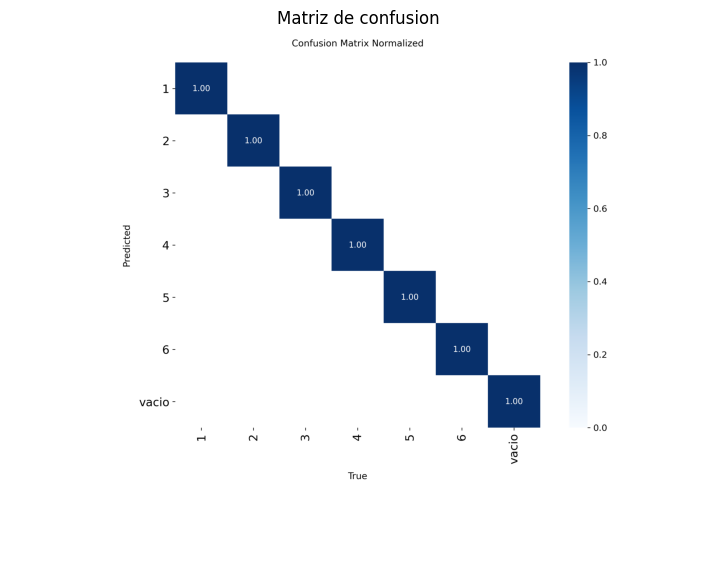

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
modelo = YOLO(Path(modelo.trainer.save_dir) / 'weights' / 'best.pt')
m = modelo.val(data='dataset', imgsz=96)
print(f'Exactitud en validacion: {m.top1:.3f}')
ver([cv2.imread(str(Path(m.save_dir) / 'confusion_matrix_normalized.png'))], ['Matriz de confusion'], ancho=9)
try:
    from google.colab import files
    files.download(str(modelo.ckpt_path))
except ImportError:
    print('Modelo guardado en', Path(modelo.ckpt_path).resolve())

In [9]:
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

X = np.array([rasgos(i) for i in DIGITOS])
mask = np.array([nombres[g] != '?' for g in GRUPO])
y = np.array([nombres[g] for g in GRUPO])[mask]; Xm = X[mask]

print('Silueta (etiqueta = dígito):', silhouette_score(Xm, y))
D = cdist(Xm, Xm)
for d in sorted(set(y)):
    i = y == d
    print(d, 'intra: %.2f' % D[np.ix_(i, i)].mean(), '| inter: %.2f' % D[np.ix_(i, ~i)].mean())

Silueta (etiqueta = dígito): 0.4113149208745177
1 intra: 5.12 | inter: 10.99
2 intra: 5.33 | inter: 11.64
3 intra: 4.93 | inter: 10.23
4 intra: 5.00 | inter: 11.83
5 intra: 5.47 | inter: 10.93
6 intra: 5.18 | inter: 10.93


In [10]:
res = modelo.predict(list(Path('dataset/val').rglob('*.png')), imgsz=96, verbose=False)
conf = np.array([r.probs.top1conf.item() for r in res])
print('conf. mínima: %.3f | media: %.3f | bajo 0.9: %.1f' % (conf.min(), conf.mean(), 100*(conf < .9).mean()))

conf. mínima: 0.826 | media: 0.994 | bajo 0.9: 1.7
